## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Step 2: Load and Explore the Data

In [2]:
# Load the Iris dataset
df = pd.read_csv('../Datasets/Iris.csv')

# Display first few rows
print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset shape:", df.shape)
print("\nColumn names:", df.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: '../Datasets/Iris.csv'

In [ ]:
# Basic statistics
print("Statistical Summary:")
df.describe()

Statistical Summary:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [ ]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Data types:
Id                 int64
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object


## Step 3: Data Visualization and Correlation Analysis

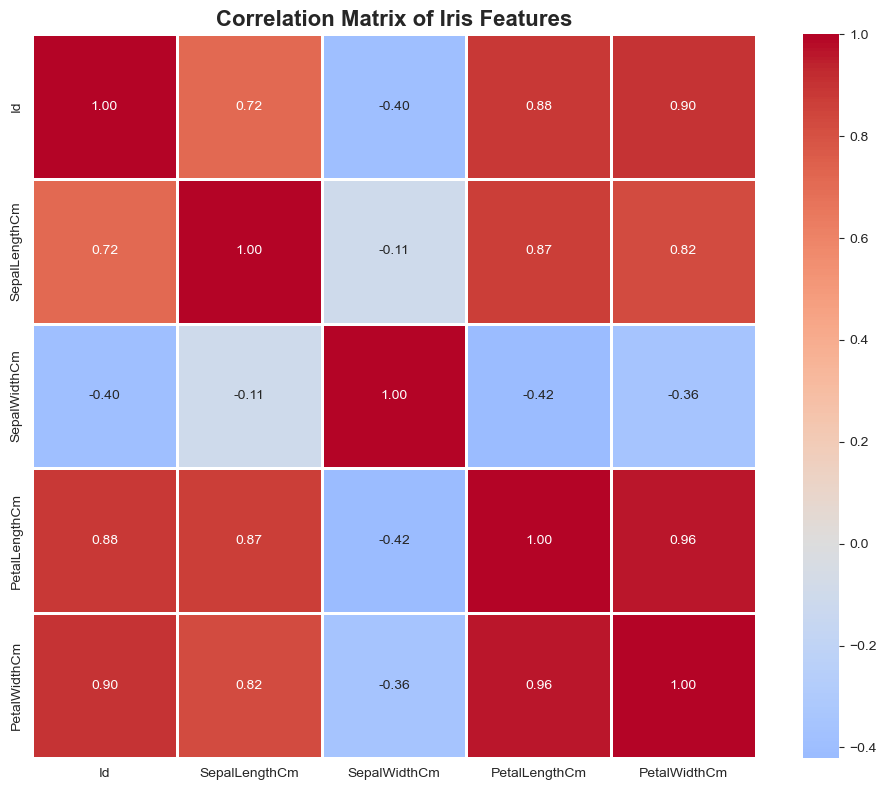


Correlation with each feature:
                     Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  \
Id             1.000000       0.716676     -0.397729       0.882747   
SepalLengthCm  0.716676       1.000000     -0.109369       0.871754   
SepalWidthCm  -0.397729      -0.109369      1.000000      -0.420516   
PetalLengthCm  0.882747       0.871754     -0.420516       1.000000   
PetalWidthCm   0.899759       0.817954     -0.356544       0.962757   

               PetalWidthCm  
Id                 0.899759  
SepalLengthCm      0.817954  
SepalWidthCm      -0.356544  
PetalLengthCm      0.962757  
PetalWidthCm       1.000000  


In [ ]:
# Select only numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Correlation matrix
plt.figure(figsize=(10, 8))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, fmt='.2f')
plt.title('Correlation Matrix of Iris Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation with each feature:")
print(correlation_matrix)

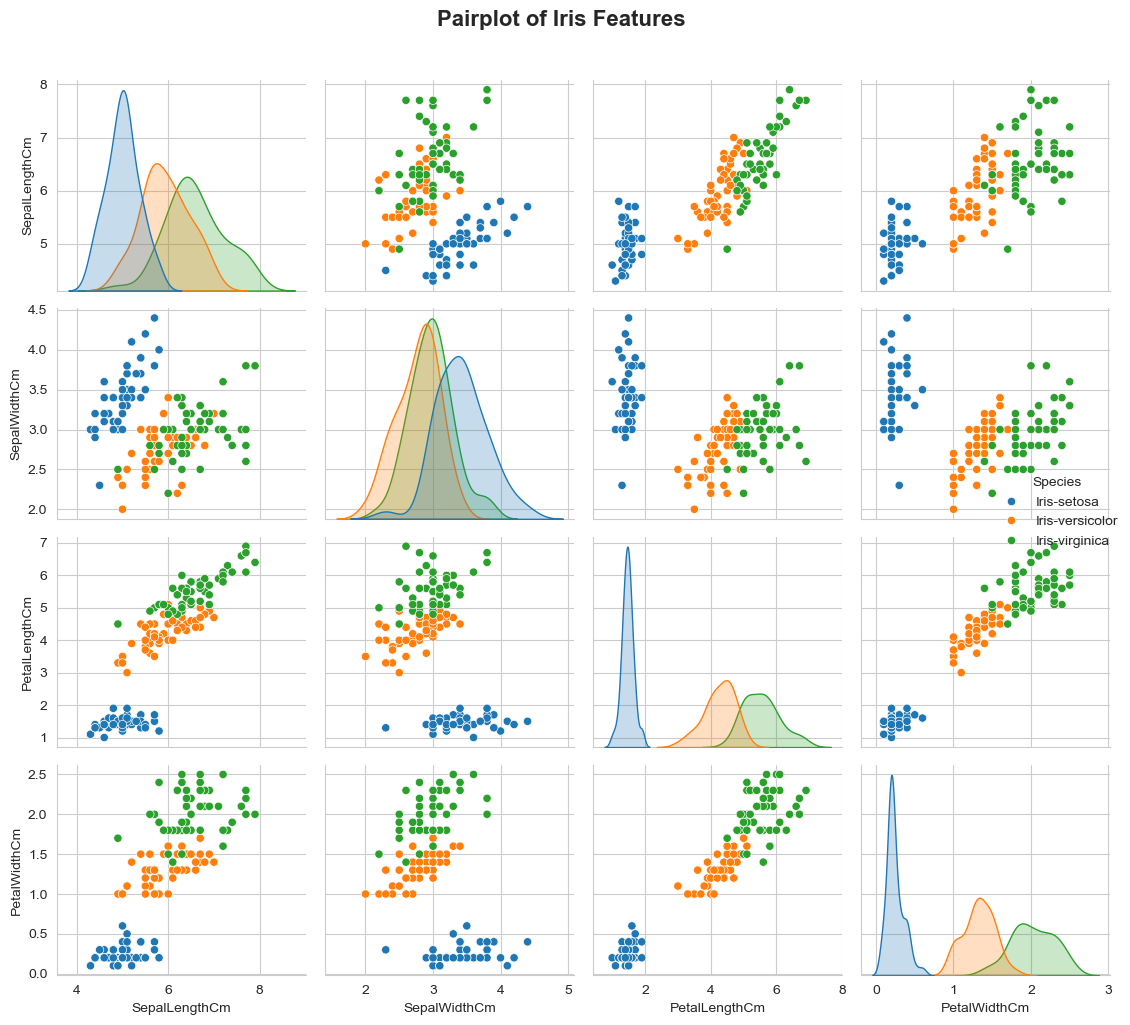

In [ ]:
# Pairplot to visualize relationships
# Remove non-numeric columns if present (like 'Id' or 'Species')
plot_cols = [col for col in df.columns if col not in ['Id', 'Species']]
if 'Species' in df.columns:
    sns.pairplot(df, hue='Species', vars=plot_cols, diag_kind='kde', height=2.5)
else:
    sns.pairplot(df[plot_cols], diag_kind='kde', height=2.5)
plt.suptitle('Pairplot of Iris Features', y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4: Prepare Data for Multi-Linear Regression

We'll predict one feature (e.g., Petal Width) using the other numerical features as predictors.

In [ ]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [ ]:
# Define features and target
# Let's predict PetalWidthCm using the other features
# Adjust column names based on your CSV structure

# Remove non-numeric columns
X = df.loc[:,["SepalLengthCm", "SepalWidthCm", "PetalLengthCm"]]

# Choose target variable (you can change this)
y = df.loc[:, "PetalWidthCm"]


print(f"Predicting: PetalWidthCm")
print(f"Using features: {X.columns.tolist()}")
print(f"\nFeature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

Predicting: PetalWidthCm
Using features: ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm']

Feature matrix shape: (150, 3)
Target vector shape: (150,)


## Step 5: Split Data into Training and Testing Sets

In [ ]:
# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 120 samples
Testing set size: 30 samples


## Step 6: Train the Multi-Linear Regression Model

In [ ]:
# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"\nIntercept (β₀): {model.intercept_:.4f}")
print("\nCoefficients (β₁, β₂, ...):")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")

Model trained successfully!

Intercept (β₀): -0.1791

Coefficients (β₁, β₂, ...):
  SepalLengthCm: -0.2379
  SepalWidthCm: 0.2430
  PetalLengthCm: 0.5367


## Step 7: Make Predictions

In [ ]:
# Make predictions on both training and testing sets
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Display first few predictions
comparison_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_test_pred[:10],
    'Difference': y_test.values[:10] - y_test_pred[:10]
})

print("First 10 predictions on test set:")
print(comparison_df)

First 10 predictions on test set:
   Actual  Predicted  Difference
0     1.2   1.572703   -0.372703
1     0.3   0.300697   -0.000697
2     2.3   2.324271   -0.024271
3     1.5   1.513445   -0.013445
4     1.4   1.459865   -0.059865
5     0.4   0.167532    0.232468
6     1.3   1.125558    0.174442
7     2.3   1.669978    0.630022
8     1.5   1.295798    0.204202
9     1.2   1.190403    0.009597


## Step 8: Evaluate Model Performance

In [ ]:

# Calculate performance metrics
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print("="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"\nTraining Set:")
print(f"  R² Score: {train_r2:.4f}")
print(f"  MSE: {train_mse:.4f}")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE: {train_mae:.4f}")

print(f"\nTesting Set:")
print(f"  R² Score: {test_r2:.4f}")
print(f"  MSE: {test_mse:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE: {test_mae:.4f}")

print("\n" + "="*50)
print("\nInterpretation:")
print(f"- R² Score: {test_r2:.2%} of variance in {target_col} is explained by the model")
print(f"- RMSE: On average, predictions are off by {test_rmse:.4f} units")
print(f"- MAE: The average absolute error is {test_mae:.4f} units")

MODEL PERFORMANCE METRICS

Training Set:
  R² Score: 0.9407
  MSE: 0.0334
  RMSE: 0.1828
  MAE: 0.1390

Testing Set:
  R² Score: 0.9269
  MSE: 0.0464
  RMSE: 0.2155
  MAE: 0.1590


Interpretation:


NameError: name 'target_col' is not defined

## Step 9: Visualize Results

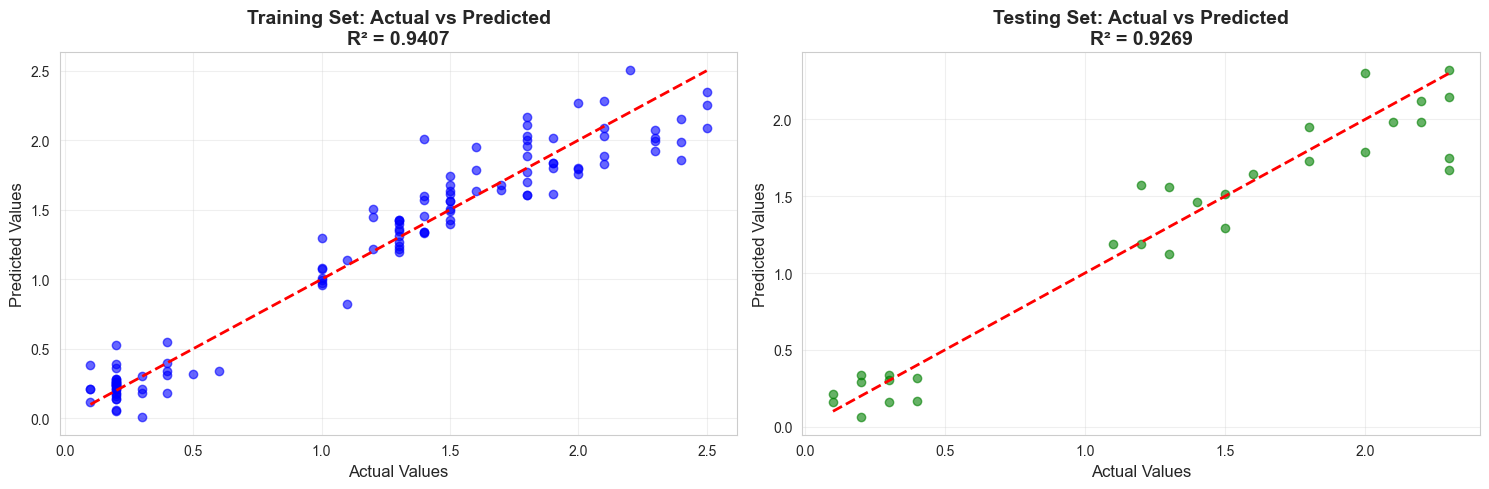

In [ ]:
# Plot 1: Actual vs Predicted
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training set
axes[0].scatter(y_train, y_train_pred, alpha=0.6, color='blue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Values', fontsize=12)
axes[0].set_ylabel('Predicted Values', fontsize=12)
axes[0].set_title(f'Training Set: Actual vs Predicted\nR² = {train_r2:.4f}', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Testing set
axes[1].scatter(y_test, y_test_pred, alpha=0.6, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Values', fontsize=12)
axes[1].set_ylabel('Predicted Values', fontsize=12)
axes[1].set_title(f'Testing Set: Actual vs Predicted\nR² = {test_r2:.4f}', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

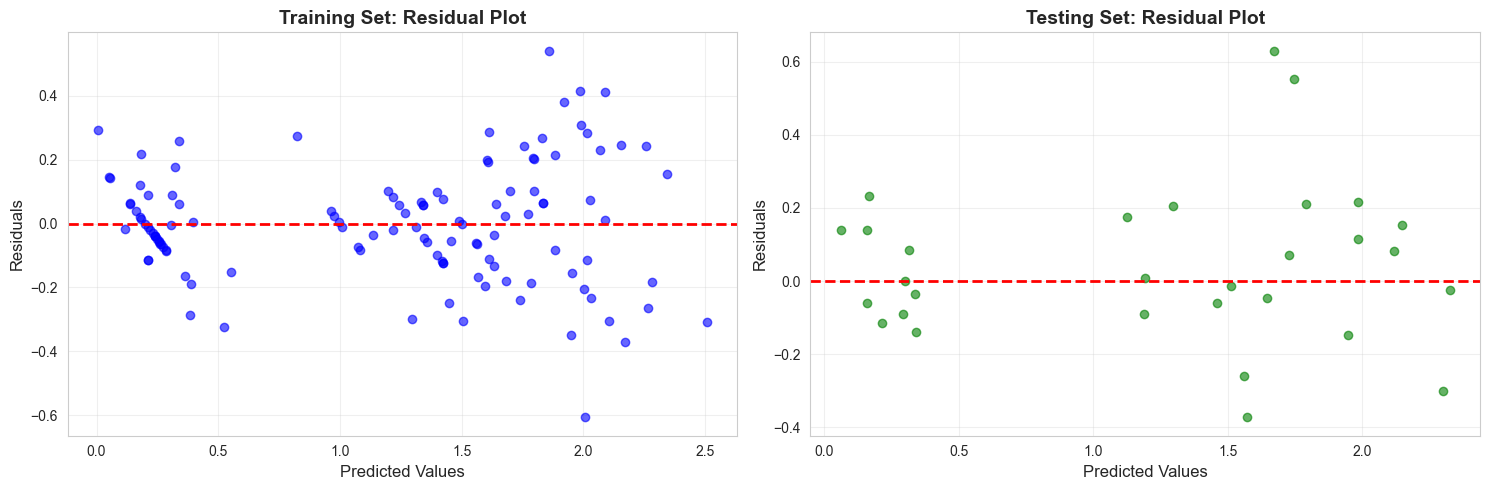

In [ ]:
# Plot 2: Residual Plot
residuals_train = y_train - y_train_pred
residuals_test = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Training residuals
axes[0].scatter(y_train_pred, residuals_train, alpha=0.6, color='blue')
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Values', fontsize=12)
axes[0].set_ylabel('Residuals', fontsize=12)
axes[0].set_title('Training Set: Residual Plot', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Testing residuals
axes[1].scatter(y_test_pred, residuals_test, alpha=0.6, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted Values', fontsize=12)
axes[1].set_ylabel('Residuals', fontsize=12)
axes[1].set_title('Testing Set: Residual Plot', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 10: Make Predictions on New Data

In [ ]:
X_test.iloc[0]

SepalLengthCm    6.1
SepalWidthCm     2.8
PetalLengthCm    4.7
Name: 73, dtype: float64

In [ ]:
# Example: Make a prediction with custom input
# Create a sample with the same features as X
sample_data = pd.DataFrame([[6.1,2.8,4.7]], columns=X.columns)

print("Sample input data:")
print(sample_data)

prediction = model.predict(sample_data)
print(f"\nPredicted {'PetalWidthCm'}: {prediction[0]:.4f}")
print(f"Actual {'PetalWidthCm'}: {y_test.iloc[0]:.4f}")
print(f"Difference: {abs(prediction[0] - y_test.iloc[0]):.4f}")

Sample input data:
   SepalLengthCm  SepalWidthCm  PetalLengthCm
0            6.1           2.8            4.7

Predicted PetalWidthCm: 1.5727
Actual PetalWidthCm: 1.2000
Difference: 0.3727


## Summary and Key Takeaways

### What We Learned:

1. **Multi-Linear Regression** uses multiple features to predict a target variable
2. **Feature Correlation** helps identify which features are most related to the target
3. **Model Coefficients** show the impact of each feature on the prediction
4. **Evaluation Metrics**:
   - **R² Score**: Proportion of variance explained (closer to 1 is better)
   - **RMSE**: Root Mean Squared Error (lower is better)
   - **MAE**: Mean Absolute Error (lower is better)
5. **Residual Analysis** helps identify if the model assumptions are met

### Model Assumptions:
- Linearity between features and target
- Independence of errors
- Homoscedasticity (constant variance of errors)
- Normality of residuals
- No multicollinearity between features

### Next Steps:
- Try different feature combinations
- Apply feature scaling if needed
- Consider polynomial features for non-linear relationships
- Try regularization techniques (Ridge, Lasso) to prevent overfitting